In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zymzym/neu-yolo/xml2yolo.py
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels.cache
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/pitted_surface_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_2.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_2.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_1.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/scratches_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_5.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/patches_3.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/rolled-in_scale_1.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/scratches_5.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_3.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/patches_5.

In [20]:
!pip install ultralytics -q

In [3]:
os.listdir("/kaggle/input")

['datasets']

In [4]:
os.listdir("/kaggle/input/datasets")

['zymzym']

In [5]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/zymzym
/kaggle/input/datasets/zymzym/neu-yolo
/kaggle/input/datasets/zymzym/neu-yolo/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images
/kaggle/input/datasets/zymzym/neu-yolo/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train
/kaggle/input/datasets/zymzym/neu-yolo/train/train/labels
/kaggle/input/datasets/zymzym/neu-yolo/train/train/images


In [6]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/zymzym/neu-yolo"):
    for file in files:
        if file.endswith(".yaml"):
            print(os.path.join(root, file))

In [7]:
for root, dirs, files in os.walk("/kaggle/input/datasets/zymzym/neu-yolo"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/zymzym/neu-yolo/xml2yolo.py
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels.cache
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/pitted_surface_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_2.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_2.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_1.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/scratches_4.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/inclusion_5.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/patches_3.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/rolled-in_scale_1.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/scratches_5.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/crazing_3.txt
/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/patches_5.

In [8]:
%%writefile data.yaml

path: /kaggle/input/datasets/zymzym/neu-yolo

train: train/train/images
val: valid/valid/images

nc: 6

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches

Writing data.yaml


In [9]:
yaml_path = "/kaggle/working/data.yaml"

In [10]:
import glob

print("Train images :", len(glob.glob("/kaggle/input/datasets/zymzym/neu-yolo/train/train/images/*")))
print("Train labels :", len(glob.glob("/kaggle/input/datasets/zymzym/neu-yolo/train/train/labels/*")))

print("Valid images :", len(glob.glob("/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/*")))
print("Valid labels :", len(glob.glob("/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels/*")))

Train images : 1770
Train labels : 1770
Valid images : 30
Valid labels : 30


In [21]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/zymzym/neu-yolo"):
    for file in files:
        if file.endswith(".yaml"):
            print(os.path.join(root, file))

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="NEU",
    name="yolov8n"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7baf5e720e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from ultralytics import YOLO

In [23]:
best_n = YOLO("/kaggle/working/runs/detect/NEU/yolov8n/weights/best.pt")

metrics_n = best_n.val()

print("YOLOv8 Nano")
print(f"Precision : {metrics_n.box.mp:.4f}")
print(f"Recall    : {metrics_n.box.mr:.4f}")
print(f"mAP@50    : {metrics_n.box.map50:.4f}")
print(f"mAP50-95  : {metrics_n.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 36.7±18.1 MB/s, size: 15.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 728.3it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s1.4s
                   all         30         64      0.649      0.779      0.799      0.493
               crazing          5          8       0.52        0.5       0.48        0.2
             inclusion   

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

In [24]:
model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="NEU",
    name="yolov8s"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [34]:
best_s = YOLO("/kaggle/working/runs/detect/NEU/yolov8s/weights/best.pt")

metrics_s = best_s.val()

print("YOLOv8 Small")
print(f"Precision : {metrics_s.box.mp:.4f}")
print(f"Recall    : {metrics_s.box.mr:.4f}")
print(f"mAP@50    : {metrics_s.box.map50:.4f}")
print(f"mAP50-95  : {metrics_s.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 33.1±16.9 MB/s, size: 14.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 732.5it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.0s1.5s
                   all         30         64      0.663      0.749      0.759      0.483
               crazing          5          8      0.689      0.558      0.701      0.333
             inclusion 

In [26]:
model_m = YOLO("yolov8m.pt")

results_m = model_m.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="NEU",
    name="yolov8m"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [27]:
best_m = YOLO("/kaggle/working/runs/detect/NEU/yolov8m/weights/best.pt")

metrics_m = best_m.val()

print("YOLOv8 Medium")
print(f"Precision : {metrics_m.box.mp:.4f}")
print(f"Recall    : {metrics_m.box.mr:.4f}")
print(f"mAP@50    : {metrics_m.box.map50:.4f}")
print(f"mAP50-95  : {metrics_m.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 32.6±16.3 MB/s, size: 15.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 705.8it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.5s2.3s
                   all         30         64      0.411       0.38      0.344      0.155
               crazing          5          8          1          0      0.118     0.0277
             inclusion 

In [36]:
best_m = YOLO("/kaggle/working/runs/detect/NEU/yolov8m/weights/best.pt")

metrics_m = best_m.val()

print("YOLOv8 Medium")
print(f"Precision : {metrics_m.box.mp:.4f}")
print(f"Recall    : {metrics_m.box.mr:.4f}")
print(f"mAP@50    : {metrics_m.box.map50:.4f}")
print(f"mAP50-95  : {metrics_m.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.2 ms, read: 34.6±17.6 MB/s, size: 13.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 826.6it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s2.5s
                   all         30         64      0.411       0.38      0.344      0.155
               crazing          5          8          1          0      0.118     0.0277
             inclusion 

In [29]:
model_l = YOLO("yolov8l.pt")

results_l = model_l.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="NEU",
    name="yolov8l"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8l, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

In [33]:
best_l = YOLO("/kaggle/working/runs/detect/NEU/yolov8l/weights/best.pt")

metrics_l = best_l.val()

print("YOLOv8 Large")
print(f"Precision : {metrics_l.box.mp:.4f}")
print(f"Recall    : {metrics_l.box.mr:.4f}")
print(f"mAP@50    : {metrics_l.box.map50:.4f}")
print(f"mAP50-95  : {metrics_l.box.map:.4f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 113 layers, 43,611,234 parameters, 0 gradients, 164.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 30.2±11.5 MB/s, size: 13.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 820.3it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/zymzym/neu-yolo/valid/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.3s3.5s
                   all         30         64      0.681      0.757       0.79      0.474
               crazing          5          8      0.496      0.375      0.476      0.217
             inclusio

In [37]:
print("="*60)
print("{:<12} {:<12} {:<12} {:<12} {:<12}".format(
    "Model","Precision","Recall","mAP50","mAP50-95"))

print("{:<12} {:.4f}      {:.4f}      {:.4f}      {:.4f}".format(
    "Nano",
    metrics_n.box.mp,
    metrics_n.box.mr,
    metrics_n.box.map50,
    metrics_n.box.map))

print("{:<12} {:.4f}      {:.4f}      {:.4f}      {:.4f}".format(
    "Small",
    metrics_s.box.mp,
    metrics_s.box.mr,
    metrics_s.box.map50,
    metrics_s.box.map))

print("{:<12} {:.4f}      {:.4f}      {:.4f}      {:.4f}".format(
    "Medium",
    metrics_m.box.mp,
    metrics_m.box.mr,
    metrics_m.box.map50,
    metrics_m.box.map))

print("{:<12} {:.4f}      {:.4f}      {:.4f}      {:.4f}".format(
    "Large",
    metrics_l.box.mp,
    metrics_l.box.mr,
    metrics_l.box.map50,
    metrics_l.box.map))

Model        Precision    Recall       mAP50        mAP50-95    
Nano         0.6486      0.7786      0.7989      0.4930
Small        0.6626      0.7493      0.7591      0.4831
Medium       0.4110      0.3802      0.3437      0.1549
Large        0.6807      0.7569      0.7898      0.4737


In [39]:
best_model = YOLO("/kaggle/working/runs/detect/NEU/yolov8n/weights/best.pt")

In [40]:
best_model.predict(
    source="/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_1.jpg: 640x640 1 crazing, 7.2ms
image 2/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 7.4ms
image 3/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 7.2ms
image 4/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 7.2ms
image 5/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_5.jpg: 640x640 2 crazings, 7.2ms
image 6/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_1.jpg: 640x640 6 inclusions, 7.2ms
image 7/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 7.2ms
image 8/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_3.jpg: 640x640 6 inclusions, 7.2ms
image 9/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_4.jpg: 640x640 4 inclusio

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}
 obb: None
 orig_img: array([[[185, 185, 185],
         [175, 175, 175],
         [171, 171, 171],
         ...,
         [102, 102, 102],
         [ 89,  89,  89],
         [ 84,  84,  84]],
 
        [[169, 169, 169],
         [171, 171, 171],
         [195, 195, 195],
         ...,
         [ 96,  96,  96],
         [ 89,  89,  89],
         [107, 107, 107]],
 
        [[192, 192, 192],
         [222, 222, 222],
         [200, 200, 200],
         ...,
         [ 83,  83,  83],
         [118, 118, 118],
         [112, 112, 112]],
 
        ...,
 
        [[253, 253, 253],
         [219, 219, 219],
         [194, 194, 194],
         ...,
         [164, 164, 164],
         [132, 132, 132],
         [123, 123, 123]],
 
        [[255, 255, 

In [45]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

preds = glob.glob("/kaggle/runs/detect/predict/*.jpg")

plt.figure(figsize=(15,10))

for i, img in enumerate(preds[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(Image.open(img))
    plt.axis("off")

plt.tight_layout()

<Figure size 1500x1000 with 0 Axes>

In [44]:
from ultralytics import YOLO

best_model = YOLO("/kaggle/working/runs/detect/NEU/yolov8n/weights/best.pt")

results = best_model.predict(
    source="/kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images",
    save=True,
    conf=0.25
)


image 1/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_1.jpg: 640x640 1 crazing, 7.4ms
image 2/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_2.jpg: 640x640 1 crazing, 7.3ms
image 3/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_3.jpg: 640x640 (no detections), 7.2ms
image 4/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_4.jpg: 640x640 2 crazings, 8.0ms
image 5/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/crazing_5.jpg: 640x640 2 crazings, 7.2ms
image 6/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_1.jpg: 640x640 6 inclusions, 7.2ms
image 7/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_2.jpg: 640x640 3 inclusions, 7.3ms
image 8/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_3.jpg: 640x640 6 inclusions, 7.4ms
image 9/30 /kaggle/input/datasets/zymzym/neu-yolo/valid/valid/images/inclusion_4.jpg: 640x640 4 inclusio

In [43]:
import os

found = False

for root, dirs, files in os.walk("/kaggle/working"):
    if "best.pt" in files:
        found = True
        print(os.path.join(root, "best.pt"))

if not found:
    print("No best.pt found")

/kaggle/working/runs/detect/NEU/yolov8l/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8s-2/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8m-2/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8n/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8s/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8m/weights/best.pt
/kaggle/working/runs/detect/NEU/yolov8n-2/weights/best.pt


Found 30 images


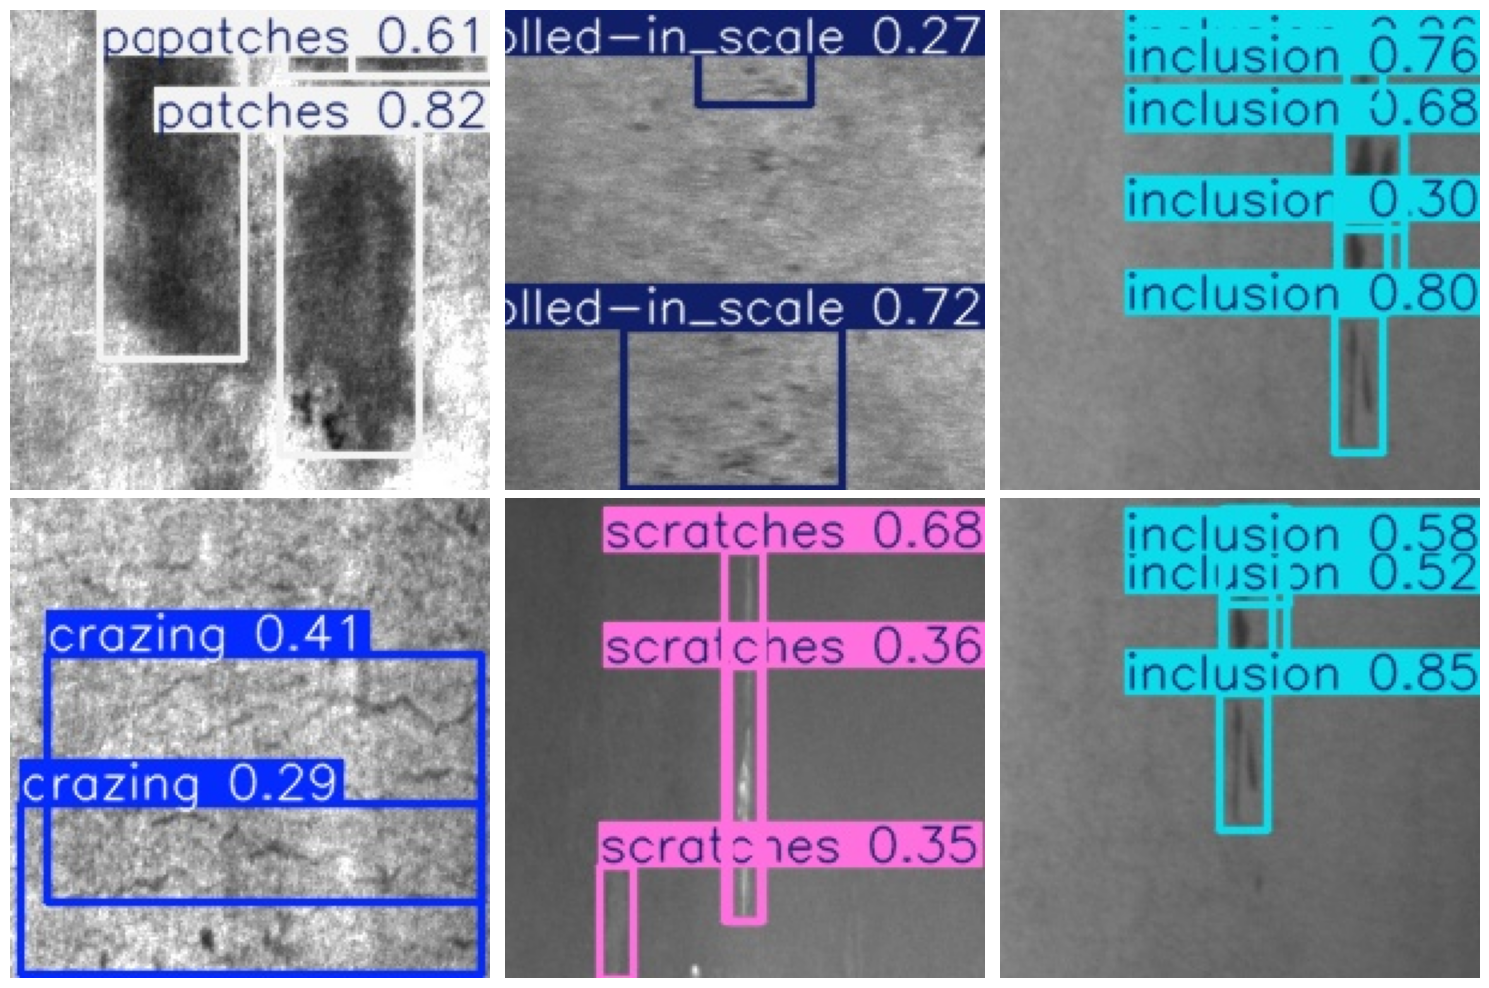

In [47]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

preds = glob.glob("/kaggle/working/runs/detect/predict-2/*.jpg")

print(f"Found {len(preds)} images")

plt.figure(figsize=(15,10))

for i, img_path in enumerate(preds[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(Image.open(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

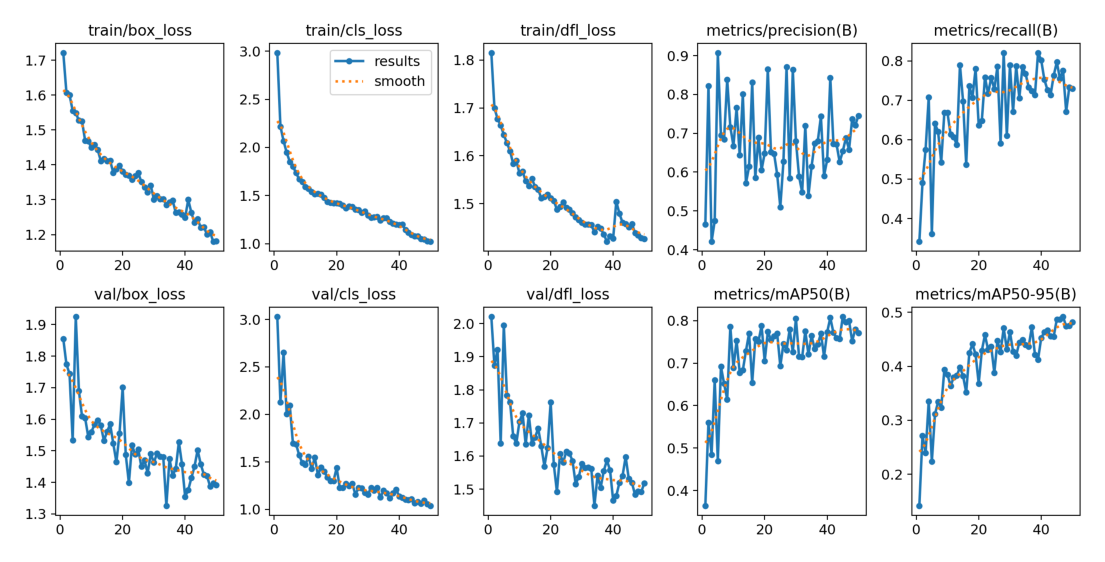

In [58]:

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/runs/detect/NEU/yolov8n/results.png")

plt.figure(figsize=(14,8))
plt.imshow(img)
plt.axis("off")

In [56]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    if "results.png" in files:
        print(os.path.join(root, "results.png"))

/kaggle/working/runs/detect/NEU/yolov8l/results.png
/kaggle/working/runs/detect/NEU/yolov8s-2/results.png
/kaggle/working/runs/detect/NEU/yolov8m-2/results.png
/kaggle/working/runs/detect/NEU/yolov8n/results.png
/kaggle/working/runs/detect/NEU/yolov8s/results.png
/kaggle/working/runs/detect/NEU/yolov8n-2/results.png


In [57]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    if "confusion_matrix.png" in files:
        print(os.path.join(root, "confusion_matrix.png"))

/kaggle/working/runs/detect/val-9/confusion_matrix.png
/kaggle/working/runs/detect/val-2/confusion_matrix.png
/kaggle/working/runs/detect/val-4/confusion_matrix.png
/kaggle/working/runs/detect/val-7/confusion_matrix.png
/kaggle/working/runs/detect/val-10/confusion_matrix.png
/kaggle/working/runs/detect/val-6/confusion_matrix.png
/kaggle/working/runs/detect/val-3/confusion_matrix.png
/kaggle/working/runs/detect/val/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8l/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8s-2/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8m-2/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8n/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8s/confusion_matrix.png
/kaggle/working/runs/detect/NEU/yolov8n-2/confusion_matrix.png
/kaggle/working/runs/detect/val-5/confusion_matrix.png
/kaggle/working/runs/detect/val-8/confusion_matrix.png


(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

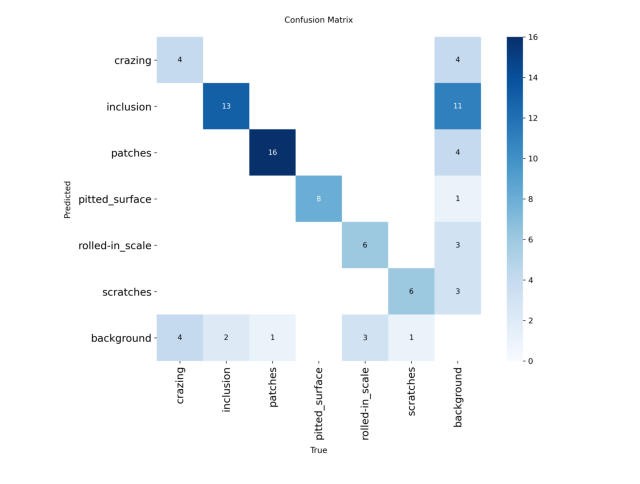

In [59]:
img = Image.open("/kaggle/working/runs/detect/NEU/yolov8n/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")